In [3]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import csv 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import ConfusionMatrixDisplay
import umap
from plotting import save_plot_scatter, save_confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd



/local/s4099699/IDL/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# Load data
X = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/train_in - Copy.csv', delimiter=',')
y = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/train_out - Copy.csv', delimiter=',').ravel().astype(int)
X_test = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/test_in - Copy.csv', delimiter=',')
y_test = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/test_out - Copy.csv', delimiter=',').astype(int)


### Task 1.1

In [8]:
unique_labels = np.unique(y)
means = np.array([X[y == label].mean(axis=0) for label in unique_labels])

n_labels = unique_labels.shape[0]
dist_matrix = []
for i in range(n_labels):
    dist_row = []
    for j in range(n_labels):
        euclidean_dist = np.linalg.norm(means[i]-means[j])
        dist_row.append(euclidean_dist)
    dist_matrix.append(dist_row)
dist_matrix = np.array(dist_matrix)
np.set_printoptions(precision=2, suppress=True, linewidth=100) # Comment out to print normally
print(dist_matrix) # Uncomment to check matrix

[[ 0.   14.45  9.33  9.14 10.77  7.52  8.15 11.86  9.91 11.49]
 [14.45  0.   10.13 11.73 10.17 11.12 10.61 10.74 10.09  9.93]
 [ 9.33 10.13  0.    8.18  7.93  7.91  7.33  8.87  7.08  8.89]
 [ 9.14 11.73  8.18  0.    9.09  6.12  9.3   8.92  7.02  8.35]
 [10.77 10.17  7.93  9.09  0.    8.    8.78  7.58  7.38  6.01]
 [ 7.52 11.12  7.91  6.12  8.    0.    6.7   9.21  6.97  8.26]
 [ 8.15 10.61  7.33  9.3   8.78  6.7   0.   10.89  8.59 10.44]
 [11.86 10.74  8.87  8.92  7.58  9.21 10.89  0.    8.47  5.43]
 [ 9.91 10.09  7.08  7.02  7.38  6.97  8.59  8.47  0.    6.4 ]
 [11.49  9.93  8.89  8.35  6.01  8.26 10.44  5.43  6.4   0.  ]]


### Task 1.2

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(X_pca.shape)
plot_scatter(X_pca, y, "pca_plot.png")

X_tsne = TSNE(n_components=2).fit_transform(X)
print(X_tsne.shape)
plot_scatter(X_tsne, y, "tsne_plot.png")

reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)
print(X_umap.shape)
plot_scatter(X_umap, y, "umap_plot.png")

# plot PCA centres
X_pca_centres = pca.fit_transform(means)
plot_scatter(X_pca_centres, unique_labels, "pca_centres_plot.png")

### Task 1.3

In [9]:
def centre_predictions(string, X, y):
    """
    uses euclidean distance from label means to predict class
    """
    predictions = []
    losses = []
    for idx, x_i in enumerate(X):
        x_i_broadcasted = np.broadcast_to(x_i, means.shape)
        dist = np.linalg.norm(x_i_broadcasted-means, axis=1)
        pred_y = np.argmin(dist)
        loss = 1 if pred_y == y[idx] else 0
        predictions.append(pred_y)
        losses.append(loss)

    percentage_true_pred = np.sum(losses) / len(losses)
    print (string, f"Percentage of true predictions: {percentage_true_pred:.4f}")

    return predictions, losses

train_centre_pred, _ = centre_predictions("(train)",X, y)

test_centre_pred, _ = centre_predictions("(test)", X_test, y_test)

(train) Percentage of true predictions: 0.8635
(test) Percentage of true predictions: 0.8040


### Task 1.4

In [11]:
neigh = KNeighborsClassifier()
neigh.fit(X,y)

train_pred, test_pred = neigh.predict(X), neigh.predict(X_test)

print(X.shape, train_pred.shape)
train_loss_arr = np.where(train_pred == y, 1, 0)
test_loss_arr = np.where(test_pred == y_test, 1, 0)

def print_pred_perc(string, losses):
    percentage_true_pred = np.sum(losses) / len(losses)
    print (string, f"Percentage of true predictions: {percentage_true_pred:.4f}")

print_pred_perc("(train)", train_loss_arr)
print_pred_perc("(test)", test_loss_arr)

# Confusion matrices

print("Shapes:", len(train_centre_pred), y.shape)

save_confusion_matrix(train_centre_pred, y, "cm_centre_pred_train.png", "Confusion Matrix: using train label centres (train).")
save_confusion_matrix(test_centre_pred, y_test, "cm_centre_pred_test.png", "Confusion Matrix: using train label centres (test).")
save_confusion_matrix(train_pred, y, "cm_knn_pred_train.png", "Confusion Matrix: using knn with train labels (train).")
save_confusion_matrix(test_pred, y_test, "cm_knn_pred_test.png", "Confusion Matrix: using knn with train labels (test).")

(1707, 256) (1707,)
(train) Percentage of true predictions: 0.9660
(test) Percentage of true predictions: 0.9080
Shapes: 1707 (1707,)


## Task 2

Run: seed 11, 10 epochs, 0.05 lr

(Train) | Avg loss: 1.166408| Accuracy: 0.773286
(Test) | Avg loss: 1.215583| Accuracy: 0.726000

Run: seed 33, 10 epochs, 0.05 lr

(Train) | Avg loss: 1.170334| Accuracy: 0.763913
(Test) | Avg loss: 1.212760| Accuracy: 0.734000

Run: seed 99, 10 epochs, 0.05 lr

(Train) | Avg loss: 1.173997| Accuracy: 0.770943
(Test) | Avg loss: 1.221727| Accuracy: 0.725000

Run: seed 297, 10 epochs, 0.05 lr

(Train) | Avg loss: 1.153130| Accuracy: 0.763913
(Test) | Avg loss: 1.201101| Accuracy: 0.735000

Run: seed 891, 10 epochs, 0.05 lr

(Train) | Avg loss: 1.182148| Accuracy: 0.763913
(Test) | Avg loss: 1.229293| Accuracy: 0.727000

Run: seed 11, 50 epochs, 0.05 lr

(Train) | Avg loss: 0.476965| Accuracy: 0.914470
(Test) | Avg loss: 0.627427| Accuracy: 0.854000

Run: seed 33, 50 epochs, 0.05 lr

(Train) | Avg loss: 0.477102| Accuracy: 0.912127
(Test) | Avg loss: 0.623824| Accuracy: 0.854000

Run: seed 99, 50 epochs, 0.05 lr

(Train) | Avg loss: 0.475719| Accuracy: 

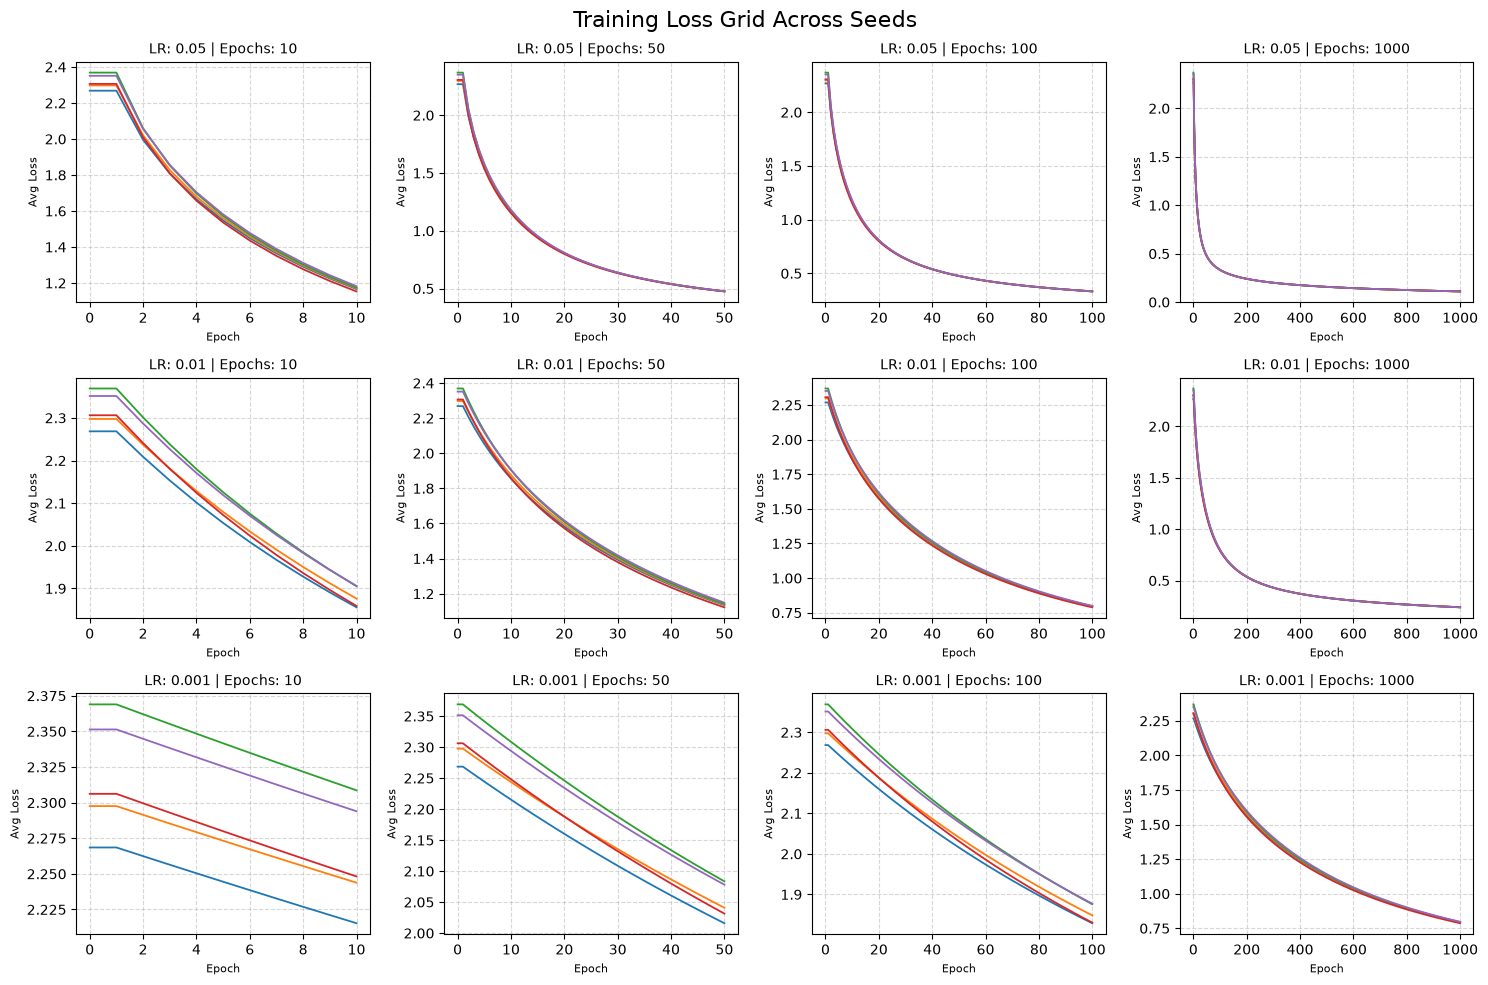

In [89]:
seeds = [11, 33, 99, 297, 891]
lrs = [0.05, 0.01, 0.001]
epochs = [10, 50, 100, 1000]

def run_experiment(seeds, lrs, epochs):
    experiment_logs= []
    figs, axes = plt.subplots(
        nrows=len(lrs),
        ncols=len(epochs),
        figsize=(15,10),
        sharex=False,
        sharey=False,
    )
    figs.suptitle(
        f"Training Loss Grid Across Seeds", fontsize=16
    )
    for idx_lr, lr in enumerate(lrs):
        for idx_n_epochs, n_epochs in enumerate(epochs):    
            ax = axes[idx_lr, idx_n_epochs]

            for _, seed in enumerate(seeds):
                np.random.seed(seed)                       

                X_in = X.T 
                in_dim = X_in.shape[0]
                n_samples = X_in.shape[1]
                bias = np.ones((1, n_samples))
                T = np.vstack((bias, X_in))
                out_dim = 10
                variance_W = 4 / (in_dim + out_dim)
                W = np.hstack((np.zeros((out_dim, 1)), np.random.normal(0, variance_W, (out_dim, in_dim))))

                f = W @ T #logit outputs
                f_max = np.max(f, axis=0)
                exp_f = np.exp(f - f_max) # prevent overflow
                log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
                target_logits = f[y, np.arange(f.shape[1])]
                L = -np.sum(target_logits - log_sum_exp) #mutliclass cross entropy loss computation
                loss = [L]

                # print(f"Epoch 0 | Avg loss: {L / n_samples:.6f}")

                for i in range(n_epochs):
                    f = W @ T #logit outputs
                    f_max = np.max(f, axis=0)
                    exp_f = np.exp(f - f_max) # prevent overflow
                    log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
                    target_logits = f[y, np.arange(f.shape[1])]
                    L = -np.sum(target_logits - log_sum_exp) #mutliclass cross entropy loss computation

                    loss.append(L)
                    # print(f"Epoch {i+1} | Avg loss: {L / n_samples:.6f}")

                    prob = exp_f / np.sum(exp_f, axis=0)
                    prob[y, np.arange(f.shape[1])] -= 1.0
                    dW = prob @ T.T
                    W = W - lr*dW/n_samples
            
                predictions = np.argmax(f, axis=0)
                accuracy = np.sum((predictions == y).astype(int))/y.shape[0]

                experiment_log = {
                    "seed": seed,
                    "epochs": n_epochs,
                    "lr": lr,
                    "avg_train_loss": L / n_samples,
                    "train_accuracy": accuracy
                }

                T = np.vstack((np.ones((1, y_test.shape[0])), X_test.T))
                predictions = np.argmax(W @ T, axis=0)

                f = W @ T #logit outputs
                f_max = np.max(f, axis=0)
                exp_f = np.exp(f - f_max) # prevent overflow
                log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
                target_logits = f[y_test, np.arange(f.shape[1])]
                L = -np.sum(target_logits - log_sum_exp) # mutliclass cross entropy loss computation
                accuracy = np.sum((predictions == y_test).astype(int))/y_test.shape[0]

                experiment_log["test_loss"] = L / L / y_test.shape[0]
                experiment_log["test_accuracy"] = accuracy
                experiment_logs.append(experiment_log)

                avg_losses = [l / n_samples for l in loss]
                ax.plot(range(n_epochs+1), avg_losses, linewidth=1.3, label=f"Seed: {seed}")

                print("="*40)
                print(f"Run: seed {seed}, {n_epochs} epochs, {lr} lr\n")                
                print(f'(Train) | Avg loss: {experiment_log["avg_train_loss"]:.6f}| Accuracy: {experiment_log["train_accuracy"]:.6f}')
                print(f"(Test) | Avg loss: {L / y_test.shape[0]:.6f}| Accuracy: {accuracy:.6f}\n")
                


            ax.set_title(f"LR: {lr} | Epochs: {n_epochs}", fontsize=10)
            ax.set_xlabel("Epoch", fontsize=8)
            ax.set_ylabel("Avg Loss", fontsize=8)
            ax.grid(True, linestyle="--", alpha=0.5)
            ax.relim()
            ax.autoscale_view()

    plt.tight_layout()
    plt.savefig(f"grid_loss_combined_seeds.png")
    plt.show()

    filename = f"experiment_a1.csv"

    df = pd.DataFrame(experiment_logs) 
    df.to_csv(filename, index=False)
    

run_experiment(seeds, lrs, epochs)

In [91]:
df = pd.read_csv("experiment_a1.csv")  
summary = df.groupby(["lr", "epochs"]).agg(
    Train_Loss=("avg_train_loss", lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
    Train_Acc=("train_accuracy", lambda x: f"{x.mean()*100:.1f}%"),
    Test_Acc=("test_accuracy", lambda x: f"{x.mean()*100:.1f}%")
).reset_index()

# Generate LaTeX string
print(summary.to_latex(index=False, column_format="cc|ccc"))

\begin{tabular}{cc|ccc}
\toprule
lr & epochs & Train_Loss & Train_Acc & Test_Acc \\
\midrule
0.001000 & 10 & 2.262±0.038 & 18.3% & 18.2% \\
0.001000 & 50 & 2.050±0.030 & 40.1% & 38.5% \\
0.001000 & 100 & 1.852±0.024 & 44.8% & 42.6% \\
0.001000 & 1000 & 0.793±0.004 & 85.7% & 80.3% \\
0.010000 & 10 & 1.880±0.024 & 43.4% & 42.3% \\
0.010000 & 50 & 1.137±0.010 & 78.0% & 72.8% \\
0.010000 & 100 & 0.796±0.004 & 85.6% & 80.3% \\
0.010000 & 1000 & 0.240±0.001 & 95.2% & 88.2% \\
0.050000 & 10 & 1.169±0.011 & 76.7% & 72.9% \\
0.050000 & 50 & 0.476±0.001 & 91.5% & 85.3% \\
0.050000 & 100 & 0.333±0.001 & 93.6% & 86.8% \\
0.050000 & 1000 & 0.110±0.000 & 97.8% & 90.2% \\
\bottomrule
\end{tabular}



## Task 3

In [14]:
def sigmoid(z):
    sigmoid = 1.0/(1.0 + np.exp(-z))
    return sigmoid 


In [49]:

def mlp(x, verbose=False):
    W_1 = np.random.normal(0, 4/4, (2,2))
    B_1 = np.zeros(2)
    f_1 = W_1 @ x + B_1
    h_1 = sigmoid(f_1)
    

    W_2 = np.random.normal(0, 4/3, (1,2))
    B_2 = np.zeros(1)
    f_2 = W_2 @ h_1 + B_2

    if verbose:
        print(h_1.shape)
        print(f_2.shape, f_2)

    return f_2

In [61]:
x_in = np.asarray([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_out = np.asarray([0, 1, 1 ,0])

lr = 0.01
n_epochs = 100 
for i in range(n_epochs):
    loss = 0
    for idx, x in enumerate(x_in):
        W_1 = np.random.normal(0, 4/4, (2,2))
        B_1 = np.zeros(2)
        f_1 = W_1 @ x + B_1
        h_1 = sigmoid(f_1)

        W_2 = np.random.normal(0, 4/3, (1,2))
        B_2 = np.zeros(1)
        f_2 = W_2 @ h_1 + B_2

        df_2 = (y_out[idx] - f_2)
        dW_2 = df_2 * h_1
        dB_2 = df_2
        W_2 = W_2 - lr * dW_2
        B_2 = B_2 - lr * dB_2

        df_1 = (h_1 * (np.ones(2) - h_1)) * (W_2.T @ df_2)
        dW_1 = df_1 * x
        dB_1 = df_1
        W_1 = W_1 - lr * dW_1
        B_1 = B_1 - lr * dB_1

        loss += df_2**2

    loss = loss * 1/4 
    print(f"Current MSE loss: {loss}")



Current MSE loss: [3.00227538]
Current MSE loss: [0.57379136]
Current MSE loss: [0.41090697]
Current MSE loss: [2.27454173]
Current MSE loss: [2.08101545]
Current MSE loss: [2.55365704]
Current MSE loss: [0.77236576]
Current MSE loss: [0.99507268]
Current MSE loss: [1.50569491]
Current MSE loss: [0.77795584]
Current MSE loss: [2.59636941]
Current MSE loss: [0.95830448]
Current MSE loss: [1.98213953]
Current MSE loss: [0.86794056]
Current MSE loss: [1.93150674]
Current MSE loss: [0.4133917]
Current MSE loss: [0.46939623]
Current MSE loss: [0.70859273]
Current MSE loss: [1.02629224]
Current MSE loss: [0.76288451]
Current MSE loss: [1.46774311]
Current MSE loss: [1.44221407]
Current MSE loss: [3.84283165]
Current MSE loss: [2.40311455]
Current MSE loss: [1.41444694]
Current MSE loss: [1.41312688]
Current MSE loss: [1.78559109]
Current MSE loss: [0.62968121]
Current MSE loss: [1.29376465]
Current MSE loss: [0.50819126]
Current MSE loss: [1.70926868]
Current MSE loss: [0.41609488]
Current M